First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN

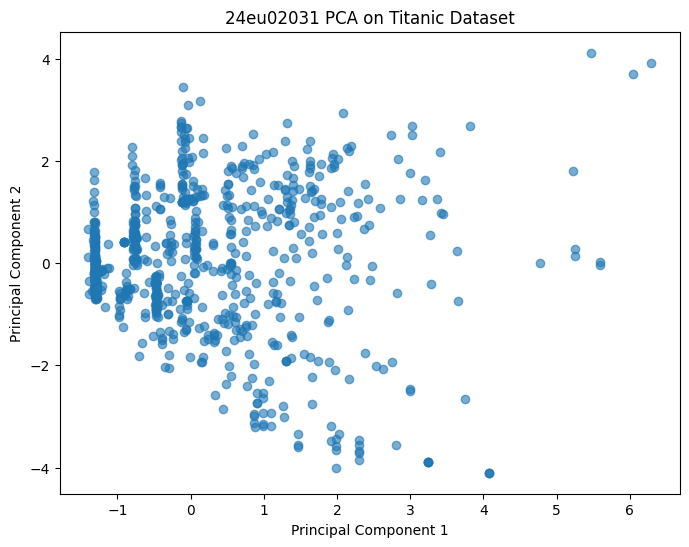


Clustered Data:
        PC1       PC2  Cluster
0 -0.970505 -0.835441        2
1  1.561132  1.277116        0
2 -0.474818 -0.469035        2
3  1.353378  1.050851        0
4 -1.304128  0.117142        2


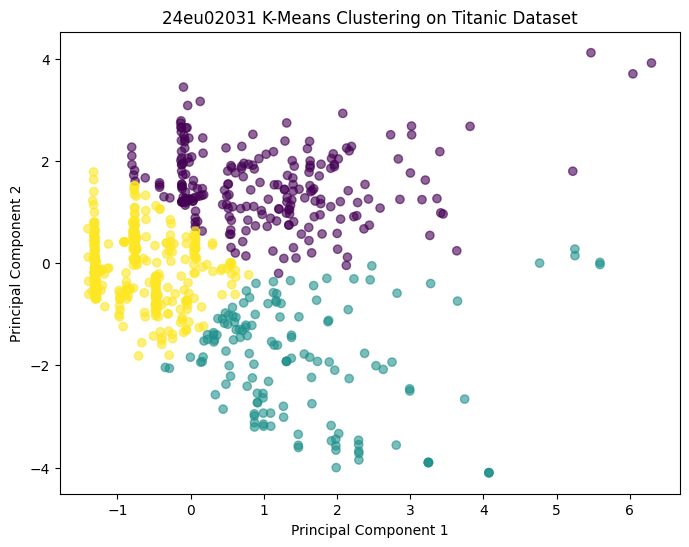


Cluster Centers:
[[ 1.00047966  1.5003107 ]
 [ 1.51893915 -1.91743071]
 [-0.85239197 -0.15682541]]


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1. Load Titanic dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

print("First 5 rows:")
print(df.head())

# 2. Select useful features
data = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']].copy()

# 3. Handle missing values
data['Age'] = data['Age'].fillna(data['Age'].median())

# 4. Convert Sex into numerical values
data['Sex'] = data['Sex'].map({
    'male': 0,
    'female': 1
})

# 5. Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

# 6. PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

print("\nPCA Result:")
print(pca_df.head())

# Explained variance
print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Variance Explained:")
print(pca.explained_variance_ratio_.sum())

# 7. PCA visualization
plt.figure(figsize=(8, 6))

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("24eu02031 PCA on Titanic Dataset")

plt.show()

# 8. K-Means Clustering
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_pca)

# Add cluster labels
pca_df['Cluster'] = clusters

print("\nClustered Data:")
print(pca_df.head())

# 9. Cluster visualization
plt.figure(figsize=(8, 6))

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=pca_df['Cluster'],
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("24eu02031 K-Means Clustering on Titanic Dataset")

plt.show()

# 10. Cluster centers
print("\nCluster Centers:")
print(kmeans.cluster_centers_)